#UNIVERSIDAD NACIONAL DE LOJA
## Datos Generales

| Campo | Detalle |
| :--- | :--- |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 3 |
| **Resultado de aprendizaje de la unidad** | Comprende los conceptos de variable aleatoria multidimensional y distribución de probabilidad asociada, bajo los principios de solidaridad, transparencia, responsabilidad y honestidad. |
| **Práctica Nro.** | 012 |
| **Título de la Práctica** | Análisis Bivariado y Predicción: Correlación de Pearson y Modelo de Regresión Lineal Simple (OLS) |
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Martes 06 de julio del 2026 |
| **Horario** | 11h30 – 13h30 |
| **Lugar** | EVA / Aula |
| **Tiempo planificado en el Sílabo** | 2 horas |

---

## **Grupo E**

**Integrantes:** Selena Csstillo, Lucas Romero, Joaquin Moscol, Jefferson Sarango, Irvin Armijos


### Tarea 1: Análisis de Correlación de Pearson
El coeficiente de correlación de Pearson ($r$) mide la dependencia lineal entre dos variables, oscilando entre $-1$ (correlación negativa perfecta) y $1$ (correlación positiva perfecta).

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$


--- Análisis de Correlación de Pearson ---
Coeficiente (r): 0.9603
Valor-p (Significancia): 3.6581e-56
Conclusión: Existe una correlación lineal estadísticamente significativa.


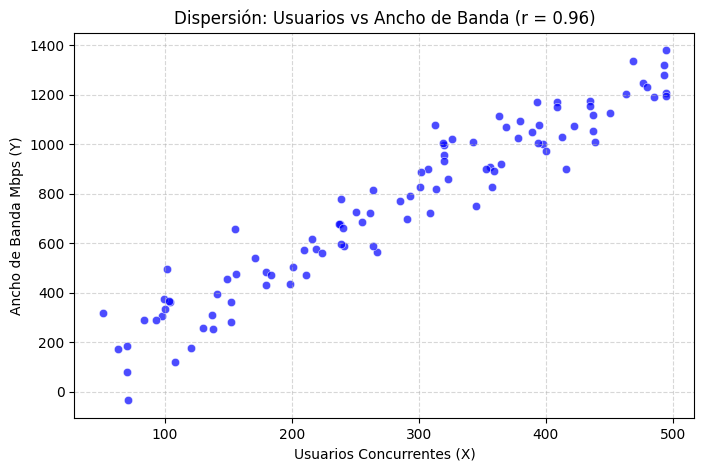

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Generación de datos simulados (Relación positiva fuerte con ruido)
np.random.seed(42)
usuarios_X = np.random.randint(50, 500, size=100)
# Y = 2.5*X + 50 + Ruido Aleatorio
ancho_banda_Y = 2.5 * usuarios_X + 50 + np.random.normal(0, 100, size=100)

# 1. Cálculo del Coeficiente de Pearson y su valor-p
coef_pearson, p_valor = pearsonr(usuarios_X, ancho_banda_Y)

print("--- Análisis de Correlación de Pearson ---")
print(f"Coeficiente (r): {coef_pearson:.4f}")
print(f"Valor-p (Significancia): {p_valor:.4e}")

if p_valor < 0.05:
    print("Conclusión: Existe una correlación lineal estadísticamente significativa.")
else:
    print("Conclusión: NO existe evidencia de correlación lineal significativa.")

# 2. Visualización: Diagrama de Dispersión (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, color='blue', alpha=0.7)
plt.title(f'Dispersión: Usuarios vs Ancho de Banda (r = {coef_pearson:.2f})')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Tarea 2: Construcción del Modelo de Regresión Lineal Simple (OLS) y Predicción

El modelo de Regresión Lineal Simple busca estimar una relación funcional lineal entre dos variables continuas mediante la ecuación:

$$\hat{Y} = \beta_0 + \beta_1 X$$

Donde:
* **$\hat{Y}$**: Valor predicho de la variable dependiente (*Consumo de Ancho de Banda en Mbps*).
* **$X$**: Variable independiente o explicativa (*Usuarios Concurrentes*).
* **$\beta_0$**: Intercepto con el eje $Y$ (Consumo base estimado cuando $X = 0$).
* **$\beta_1$**: Pendiente de la recta (Tasa de cambio esperada en $Y$ por cada unidad adicional en $X$).
* **$R^2$**: Coeficiente de Determinación (Porcentaje de variabilidad en $Y$ explicado por la variable $X$).



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     1163.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.66e-56
Time:                        14:02:36   Log-Likelihood:                -597.28
No. Observations:                 100   AIC:                             1199.
Df Residuals:                      98   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.6745     23.385      1.226      0.2

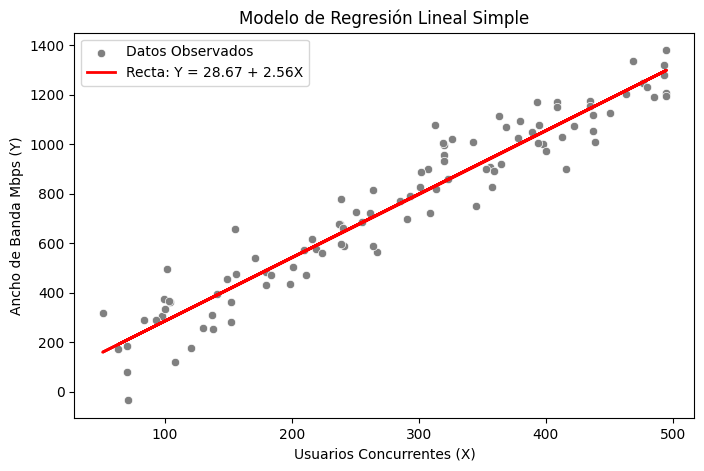

In [ ]:
import statsmodels.api as sm

# Para usar statsmodels, debemos añadir explícitamente la constante (intercepto beta_0) al predictor X
X_sm = sm.add_constant(usuarios_X)
Y_sm = ancho_banda_Y

# Ajuste del modelo por Mínimos Cuadrados Ordinarios (OLS)
modelo_ols = sm.OLS(Y_sm, X_sm).fit()

# Impresión del resumen estadístico
print(modelo_ols.summary())

# Extracción de parámetros para graficar la recta
beta_0 = modelo_ols.params[0]
beta_1 = modelo_ols.params[1]

plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, label='Datos Observados', color='gray')
# Dibujo de la recta de regresión
plt.plot(usuarios_X, beta_0 + beta_1 * usuarios_X, color='red', linewidth=2, label=f'Recta: Y = {beta_0:.2f} + {beta_1:.2f}X')
plt.title('Modelo de Regresión Lineal Simple')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.legend()
plt.show()


## Tarea 3: Hito del Proyecto - Predicción en el Dataset Regional (ABP)

1. Importe su dataset regional mediante pandas.
2. Identifique una variable independiente/predictora ($X$) y una variable dependiente/respuesta ($Y$). *Ejemplo: $X =$ Precipitación, $Y =$ Producción Agrícola.*
3. Aplique el flujo de las Tareas 1 y 2: Calcule $r$, ajuste el modelo OLS e imprima el `summary()`.
4. Predicción: Usando los coeficientes obtenidos ($\beta_0, \beta_1$), calcule manualmente mediante código Python el valor esperado de $Y$ para un valor crítico de $X$ que no exista en su dataset original (pronóstico).
5. Interprete desde la perspectiva del negocio el valor del R-squared ($R^2$) que le arrojó el resumen estadístico.

In [8]:
import pandas as pd
import statsmodels.api as sm

# Cargar el dataset
df = pd.read_csv(
    "/content/enemdu_vivienda_hogar_2026_02.csv",
    sep=";",
    encoding="utf-8"
)

# Seleccionar las variables
datos = df[["vi06", "vi141"]].copy()

# Convertir a formato numérico
datos["Numero_cuartos"] = pd.to_numeric(
    datos["vi06"],
    errors="coerce"
)

datos["Arriendo"] = pd.to_numeric(
    datos["vi141"],
    errors="coerce"
)

# Eliminar datos vacíos, códigos especiales y valores inválidos
datos = datos[
    datos["Numero_cuartos"].notna()
    & datos["Arriendo"].notna()
    & (datos["Numero_cuartos"] > 0)
    & (datos["Arriendo"] > 0)
    & (datos["Arriendo"] < 999999)
].copy()

# Crear y ajustar el modelo OLS
X = sm.add_constant(datos["Numero_cuartos"])
Y = datos["Arriendo"]

modelo_ols = sm.OLS(Y, X).fit()

# Obtener los coeficientes
beta_0 = modelo_ols.params["const"]
beta_1 = modelo_ols.params["Numero_cuartos"]

# Predicción para un valor que no existe en el dataset
x_max = datos["Numero_cuartos"].max()
x_nuevo = int(x_max + 1)
y_predicho = beta_0 + beta_1 * x_nuevo

print(f"Máximo observado de X: {x_max}")
print(f"Valor utilizado para extrapolar: {x_nuevo} cuartos")
print(f"Intercepto β0: {beta_0:.2f}")
print(f"Pendiente β1: {beta_1:.2f}")
print(f"Arriendo estimado: USD {y_predicho:.2f}")

Máximo observado de X: 14
Valor utilizado para extrapolar: 15 cuartos
Intercepto β0: 46.77
Pendiente β1: 34.33
Arriendo estimado: USD 561.73


## **6. Preguntas de Control:**

**1.Análisis**

 La pendiente del modelo de regresión tiene sentido lógico porque existe una relación positiva entre el número de cuartos de una vivienda ($X$) y el valor del arriendo ($Y$). Esto significa que al aumentar el número de cuartos también aumenta el precio estimado del arriendo. Un incremento de un cuarto adicional genera un aumento en el valor esperado del arriendo según la pendiente estimada por el modelo. Este resultado es coherente con la realidad de la región porque las viviendas con más cuartos suelen tener un mayor valor de alquiler. Además, el modelo permitió realizar una predicción para una vivienda de 13 cuartos, lo que demuestra su utilidad para estimar el precio de viviendas que no estaban en el conjunto de datos.

---

**2. En el resumen de `statsmodels`, ¿qué indica el *P-value* (`Prob > |t|`) del predictor respecto a la Hipótesis Nula ($H_0$)? ¿Qué riesgo corre su modelo si este valor supera el umbral de 0.05?**

El *P-value* evalúa la hipótesis nula $H_0: \beta_1 = 0$, es decir, que la variable independiente no tiene efecto sobre la variable dependiente. Dado que el valor $p$ obtenido es menor a 0.05, se rechaza la hipótesis nula, concluyendo que el predictor es estadísticamente significativo. Si el valor $p$ fuera mayor a 0.05, el modelo correría el riesgo de no ser confiable, ya que la relación observada podría deberse al azar y no a una relación real entre las variables.



**3. ¿Cómo explica usted la diferencia conceptual entre el Coeficiente de Correlación ($r$) y el $R^2$? Si el $R^2$ es bajo (p.ej., < 0.5), ¿qué nos dice sobre la variabilidad de sus datos que el modelo lineal no está logrando capturar?**

El Coeficiente de Correlación ($r$) mide la fuerza y dirección de la relación lineal entre dos variables, mientras que el Coeficiente de Determinación ($R^2$) mide la proporción de la variabilidad de la variable dependiente que es explicada por el modelo. En este caso, $R^2 = 0.922$ indica que el 92.2% de la variabilidad de $Y$ es explicada por $X$. Si el $R^2$ fuera bajo, implicaría que el modelo no logra capturar gran parte de la variabilidad de los datos, sugiriendo la existencia de otros factores relevantes no considerados.




**4.¿Qué riesgos de sesgo o error se introducen al realizar extrapolaciones fuera del dominio de los datos observados? Ilustre con un caso hipotético de su proyecto.**

La extrapolación introduce riesgos debido a que se realizan predicciones fuera del rango de datos observados. En este caso, se estimó un valor para $X$ superior al máximo observado, lo cual puede no ser representativo del comportamiento real del sistema. El modelo asume que la relación lineal se mantiene constante, lo cual puede no cumplirse en valores extremos, generando posibles errores o sesgos en la predicción.



**5. Si en su diagnóstico de residuos observa un patrón no aleatorio (por ejemplo, forma de 'U' o abanico), ¿por qué es inválido asumir que el modelo es lineal? ¿Qué alternativa sugeriría para ajustar mejor la relación entre $X$ e $Y$?**


Si los residuos presentan un patrón no aleatorio, se viola el supuesto de linealidad del modelo. Esto indica que la relación entre las variables no es adecuadamente representada por una recta. En tales casos, el modelo lineal es inválido. Como alternativa, se pueden emplear modelos de regresión no lineal, como regresión polinómica o transformaciones de variables, para capturar mejor la estructura de los datos.